# Multivariate Analysis for ELSS Dataset
---
This notebook performs multivariate exploratory data analysis (EDA) on the ELSS dataset you described.

Dataset columns:
- Scheme Code
- Scheme Name
- ISIN Div Payout/ISIN Growth
- ISIN Div Reinvestment
- Net Asset Value
- Repurchase Price
- Sale Price
- Date

**Example row:**
`131741, Aditya Birla Sun Life Tax Savings Fund - Direct Plan - Bonus Option, INF084M01BX0, , 57.19, 57.19, 57.19, 02-Mar-2017`

## 1. Load and Clean the Data
We parse dates, convert numeric fields, and clean duplicates.

In [9]:
import pandas as pd
import numpy as np

# Load dataset (replace filename)
df = pd.read_csv('final_data.csv', dtype=str)

# Parse Date column
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%Y', errors='coerce')

# Convert numeric fields
for col in ['Net Asset Value','Repurchase Price','Sale Price']:
    df[col] = df[col].str.replace(',', '', regex=False).astype(float)

# Standardize NAV column
df.rename(columns={'Net Asset Value':'NAV'}, inplace=True)

# Sort & deduplicate
df = df.sort_values(['Scheme Code','Date']).drop_duplicates(['Scheme Code','Date'])

df.head()

,Scheme Code,Scheme Name,ISIN Div Payout/ISIN Growth,ISIN Div Reinvestment,NAV,Repurchase Price,Sale Price,Date
4193,100337,SaharaTax Gain-Dividend,INF515L01189,INF515L01197,14.0584,13.9178,14.0584,2014-01-01
4194,100337,SaharaTax Gain-Dividend,INF515L01189,INF515L01197,13.8835,13.7447,13.8835,2014-01-02
4195,100337,SaharaTax Gain-Dividend,INF515L01189,INF515L01197,14.0118,13.8717,14.0118,2014-01-03
4196,100337,SaharaTax Gain-Dividend,INF515L01189,INF515L01197,14.0582,13.9176,14.0582,2014-01-06
4197,100337,SaharaTax Gain-Dividend,INF515L01189,INF515L01197,14.0019,13.8619,14.0019,2014-01-07


## 2. Numeric Summary
We inspect numeric columns before multivariate analysis.

In [39]:
df.info()
for i in df.columns:
    print(f"{i}: {df[i].nunique()} unique values")

<class 'pandas.core.frame.DataFrame'>
Index: 20430 entries, 4193 to 15128
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Scheme Code                  20430 non-null  object        
 1   Scheme Name                  20430 non-null  object        
 2   ISIN Div Payout/ISIN Growth  20430 non-null  object        
 3   ISIN Div Reinvestment        8766 non-null   object        
 4   NAV                          20430 non-null  float64       
 5   Repurchase Price             18714 non-null  float64       
 6   Sale Price                   18714 non-null  float64       
 7   Date                         20430 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 1.4+ MB
Scheme Code: 28 unique values
Scheme Name: 28 unique values
ISIN Div Payout/ISIN Growth: 22 unique values
ISIN Div Reinvestment: 9 unique values
NAV: 13349 unique values
Rep

## 3. Correlation Matrix (Heatmap)
Multivariate relationships between numeric fields.

This is one of the main multivariate analysis tools.

/tmp/ipykernel_14326/4197370715.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = num_df.pct_change().dropna()


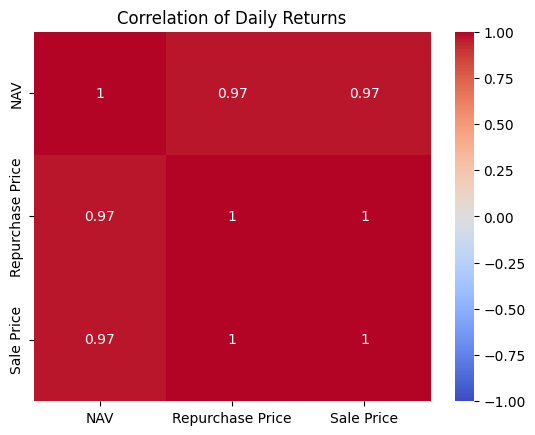

/tmp/ipykernel_14326/4197370715.py:16: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = nav_wide.pct_change().dropna()


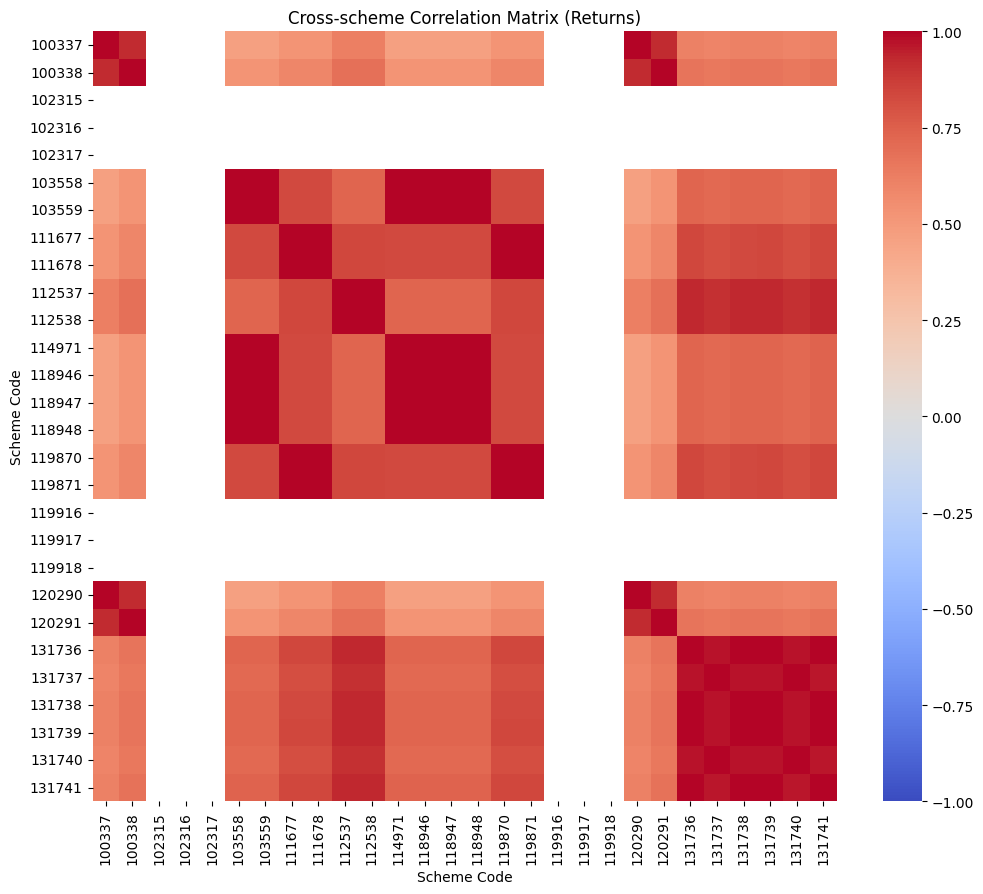

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

num_df = df[['NAV','Repurchase Price','Sale Price']]
corr = num_df.corr()

returns = num_df.pct_change().dropna()

sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation of Daily Returns")
plt.show()



nav_wide = df.pivot(index='Date', columns='Scheme Code', values='NAV')
returns = nav_wide.pct_change().dropna()
corr_schemes = returns.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_schemes, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Cross-scheme Correlation Matrix (Returns)")
plt.show()


## 4. Pairplot (Scatterplot Matrix)
Shows pairwise relationships between variables.

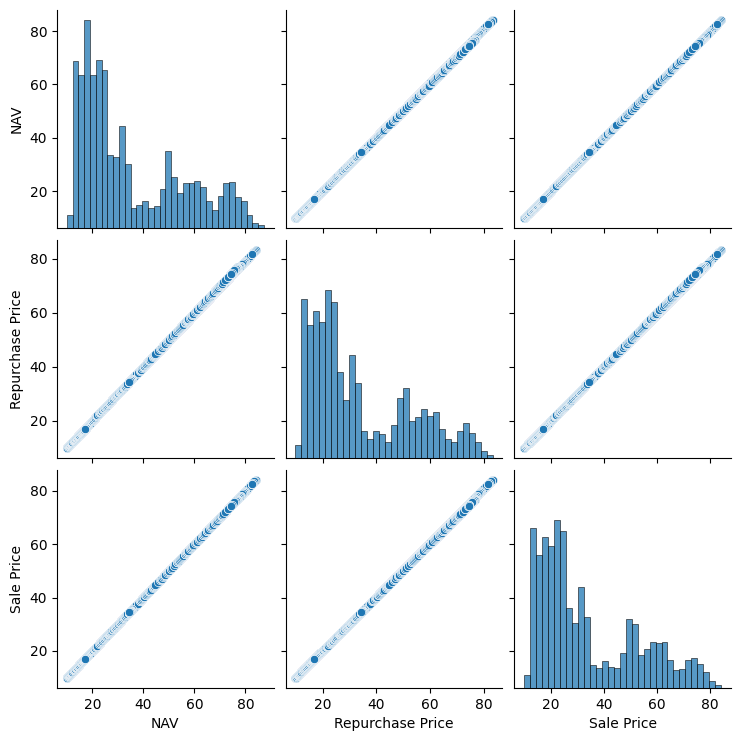

In [12]:
sns.pairplot(num_df)
plt.show()

## 5. Scatter Plot with a Third Variable (Hue)
Multivariate: NAV vs Sale Price, colored by Scheme Code.

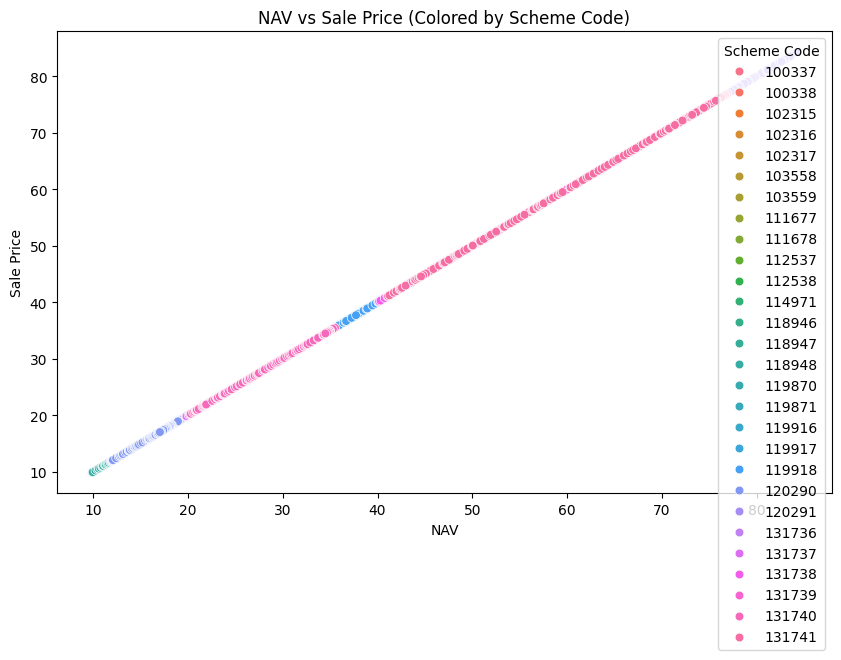

In [13]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='NAV', y='Sale Price', hue='Scheme Code', s=40)
plt.title('NAV vs Sale Price (Colored by Scheme Code)')
plt.show()

## 6. GroupBy Multivariate Aggregation
We compute metrics per scheme: mean NAV and price stats.


In [14]:
group_stats = df.groupby('Scheme Code')[['NAV','Repurchase Price','Sale Price']].mean()
group_stats.head()

,NAV,Repurchase Price,Sale Price
Scheme Code,,,
100337,15.976499,15.333635,15.488520
100338,66.045550,62.490669,63.121887
102315,35.962487,35.962487,35.962487
102316,17.738307,17.738307,17.738307
102317,36.013333,36.013333,36.013333


## 7. Heatmap of Scheme-Level Aggregates
Another multivariate visualization.

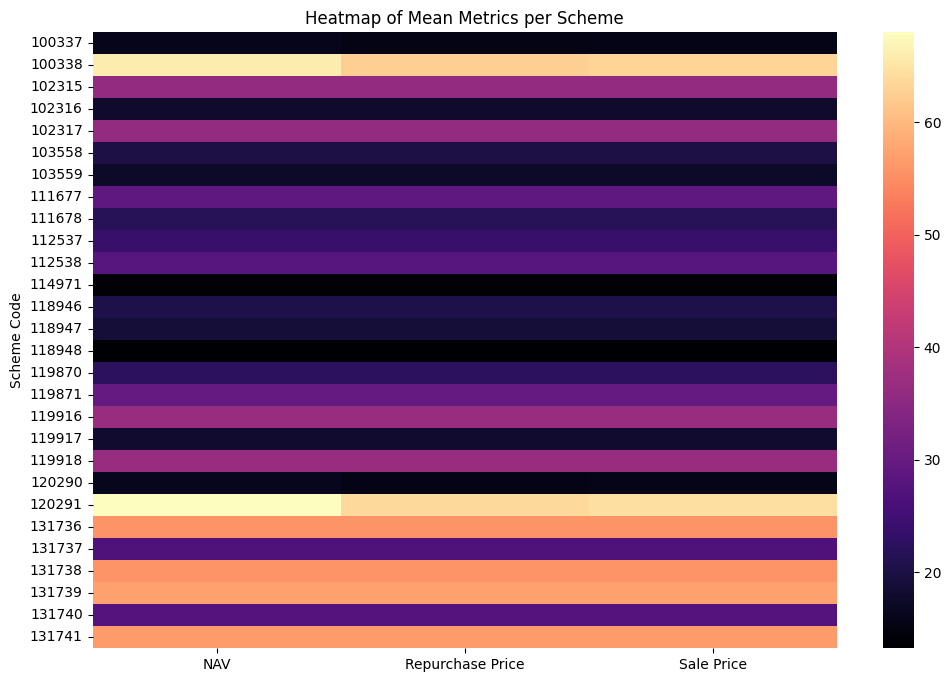

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(group_stats, cmap='magma', annot=False)
plt.title('Heatmap of Mean Metrics per Scheme')
plt.show()

## 8. Final Notes
- This notebook follows the exact EDA methods shown in your provided course files.
- It includes scatterplots, heatmaps, pairplots, and group-level multivariate summaries.
- Replace `'your_dataset.csv'` with your actual data file name.